<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 138.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 146.7 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 95.6 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-06-09 10:48:30--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  43.0MB/s    in 3.5s    

2026-06-09 10:48:34 (43.5 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



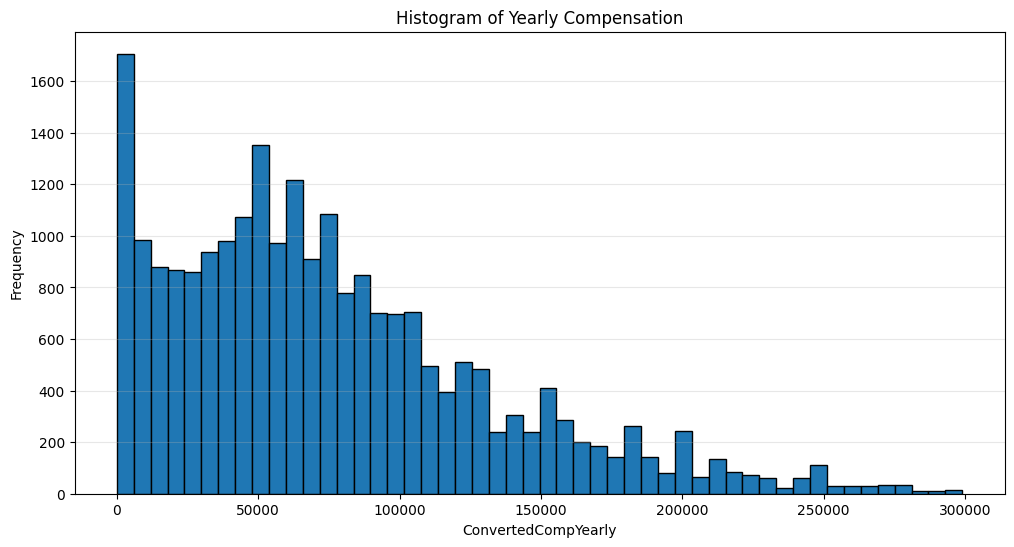

In [15]:
## Write your code here
Comp_df = df[['ConvertedCompYearly']].dropna()

#filtering
CompTotal = Comp_df[Comp_df['ConvertedCompYearly'] < 300000]

plt.figure(figsize=(12,6))

plt.hist(CompTotal['ConvertedCompYearly'], bins=50, edgecolor='black')

plt.title('Histogram of Yearly Compensation')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



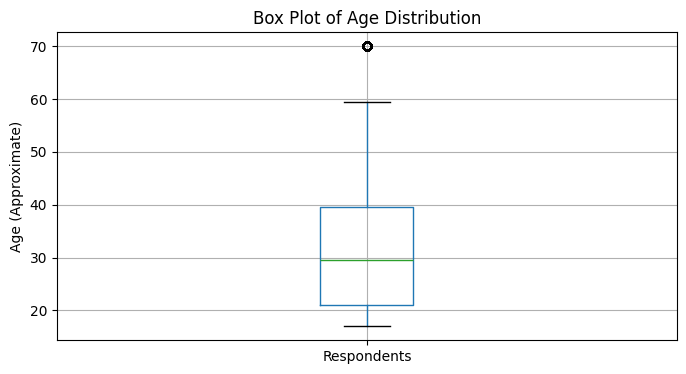

In [14]:
## Write your code here
#age to numerical for boxplot
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70}

df['Age_Numeric'] = df['Age'].map(age_map)

df_Age = df.dropna(subset=['Age_Numeric'])

#plot boxplot
plt.figure(figsize=(8, 4))
df_Age.boxplot(column='Age_Numeric')

plt.title('Box Plot of Age Distribution')
plt.ylabel('Age (Approximate)')
plt.xticks([1], ['Respondents'])

plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



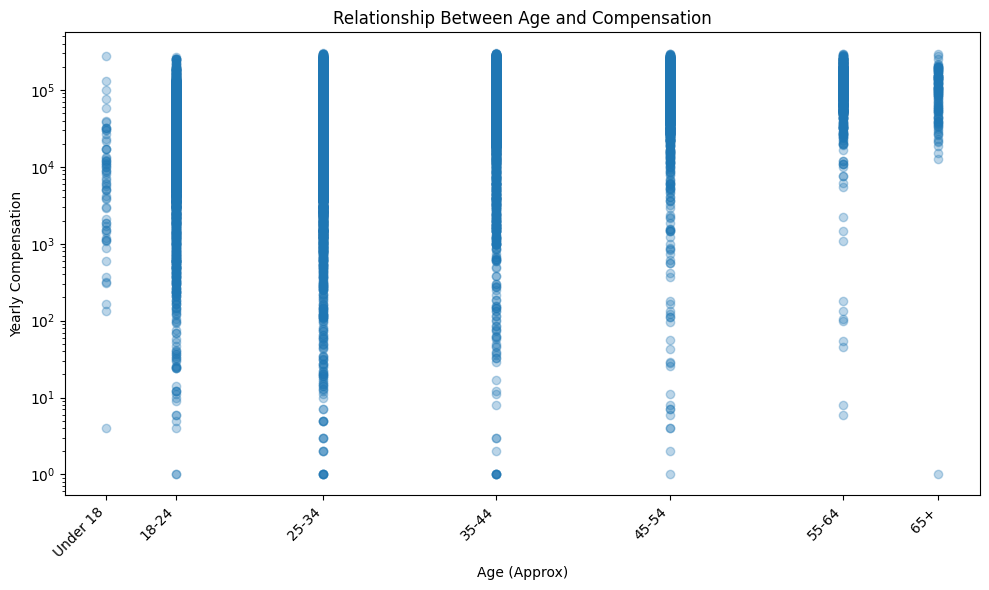

In [26]:
## Write your code here
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5 ,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_Numeric'] = df['Age'].map(age_map)
df['ConvertedCompYearly'].value_counts()

Comp_df= df[['ConvertedCompYearly', 'Age_Numeric']].copy()
Comp_df = Comp_df.dropna()

Comp_df = Comp_df[Comp_df['ConvertedCompYearly'] < 300000]

plt.figure(figsize=(10, 6))
           
plt.scatter(Comp_df['Age_Numeric'], Comp_df['ConvertedCompYearly'], alpha=0.3,)
           
plt.title('Relationship Between Age and Compensation')
plt.xlabel('Age (Approx)')
plt.ylabel('Yearly Compensation')
plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    rotation=45, ha='right')
plt.yscale('log')
plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [35]:
df['JobSatPoints_6'].unique()

array([   nan,   0.  ,  25.  ,  30.  ,  60.  , 100.  ,  20.  ,  50.  ,
        15.  ,  10.  ,   5.  ,  80.  ,   8.  ,  65.  ,  90.  ,  75.  ,
        35.  ,  40.  ,  33.  ,  70.  ,  17.  ,   7.  ,  12.  ,  13.  ,
         9.  ,  21.  ,  18.  ,  95.  ,   2.  ,  45.  ,  34.  ,  16.  ,
        78.  ,  85.  ,   1.  ,  14.  ,  31.  ,  11.  ,  23.  ,  28.  ,
        81.  ,   6.25,   6.  ,  55.  ,   3.  ,  22.  ,  42.  ,   4.  ,
        89.  ,  99.  ,  12.5 ,  36.  ,  27.  ,  24.  ,  19.  ,  87.  ,
        88.  ,  29.  ,  33.33,  33.3 ,  37.  ,  39.  ,  77.  ,  68.  ,
        26.  ,  98.  ,  32.  ,  66.  ,  57.  ,  82.  ,  94.  ,  61.  ,
        43.  ,  69.  ,  76.  ,  73.  ,  17.5 ,  46.  ,  49.  ,  52.  ,
        97.  ,  96.  ,  67.  ,  91.  ,  86.  ,  56.  ,  41.  ,  74.  ,
        51.  ,  48.  ,  44.  ,  64.  ,  54.  ,  63.  ])

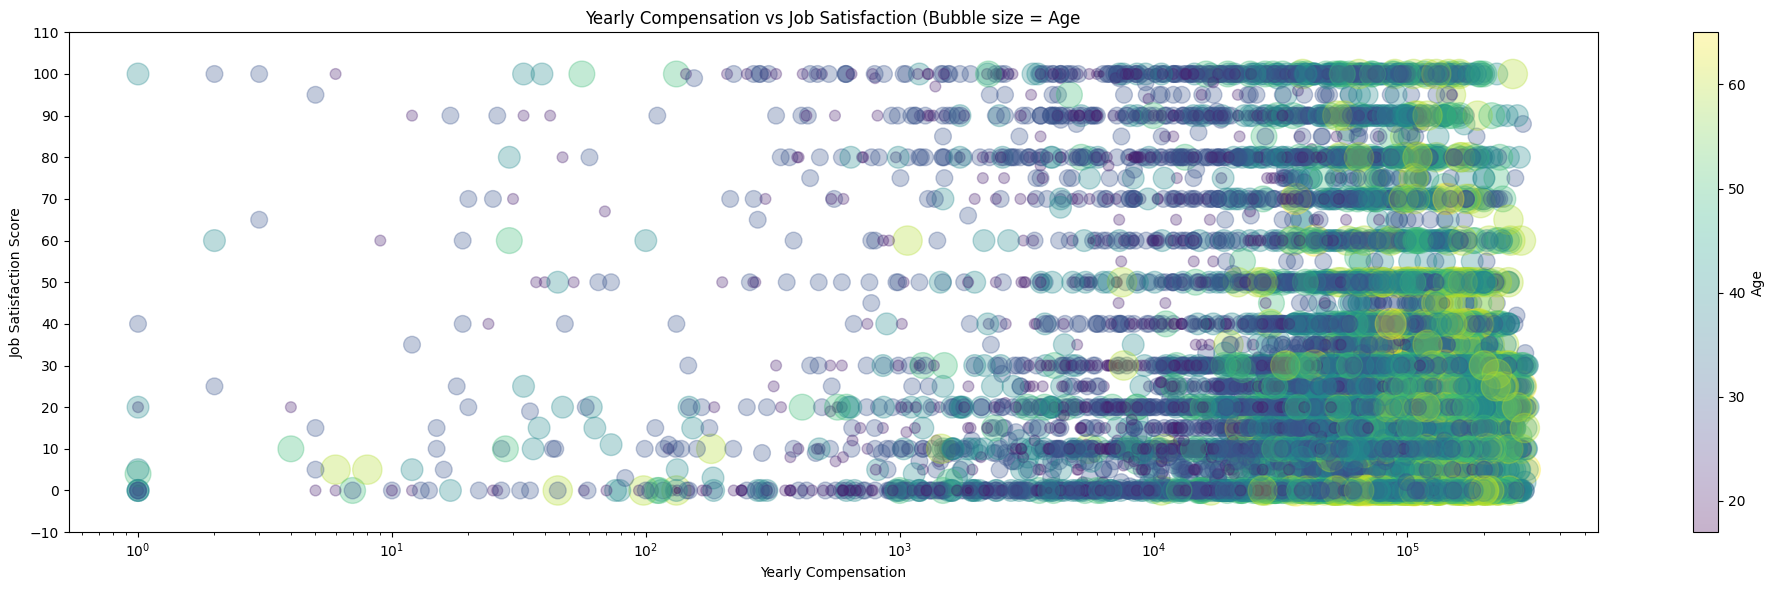

In [42]:
## Write your code here
df['ConvertedCompYearly'].unique()

age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,    
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65}

df['Age_num'] = df['Age'].map(age_map)

Comp_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_num']].copy()

#log scale, help with extreme salaries
Comp_df = Comp_df[Comp_df['ConvertedCompYearly'] < 300000]

Comp_df = Comp_df.dropna()

#bubble scale
bubble_size = (Comp_df['Age_num'] - Comp_df['Age_num'].min()) * 10 + 20

#plotting - s=controls bubblesize
plt.figure(figsize=(20, 6))

scatter = plt.scatter(
    Comp_df['ConvertedCompYearly'],
    Comp_df['JobSatPoints_6'],
    s=bubble_size,
    c=Comp_df['Age_num'],
    cmap='viridis',
    alpha=0.3) #lower to reduce overlapping

plt.colorbar(scatter, label='Age')
        
plt.title('Yearly Compensation vs Job Satisfaction (Bubble size = Age')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Score')
plt.ylim(-0.6, 12.5) # distance between scale
plt.yticks(range(-10, 120, 10)) #spaced ticks - increasing by 10's to reduce crowding
plt.xscale('log')
plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



In [43]:
## Write your code here
df['MainBranch'].unique()

<StringArray>
[                                                       'I am a developer by profession',
                                                                 'I am learning to code',
                                                           'I code primarily as a hobby',
 'I am not primarily a developer, but I write code sometimes as part of my work/studies',
                              'I used to be a developer by profession, but no longer am']
Length: 5, dtype: str

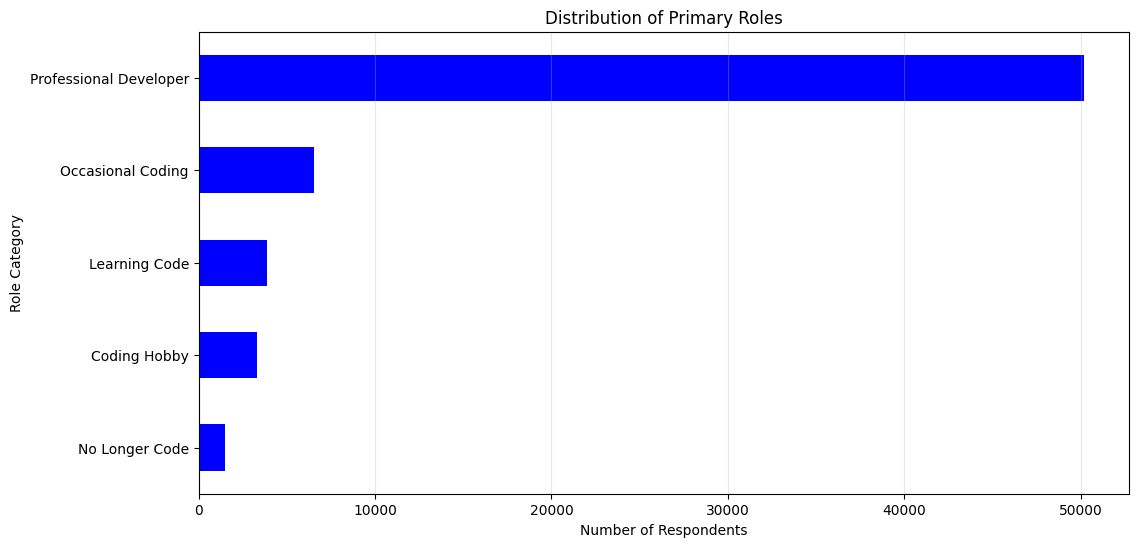

In [57]:
#MainBranch Labels and tidy - 
df['Primary_roles'] =(df['MainBranch']
.str.replace('I am a developer by profession', 'Professional Developer', regex=False)
.str.replace('I am learning to code', 'Learning Code', regex=False)
.str.replace('I code primarily as a hobby', 'Coding Hobby', regex=False)
.str.replace('I am not primarily a developer, but I write code sometimes as part of my work/studies', 'Occasional Coding', regex=False)
.str.replace('I used to be a developer by profession, but no longer am', 'No Longer Code', regex=False))

def Simplify_role(emp):
    emp = str(emp)
    if emp == 'I am a developer by profession':
        return 'Professional Developer'
    elif emp == 'I am learning to code':
        return 'Learning Code'
    elif emp == 'I code primarily as a hobby':
        return 'Coding Hobby'
    elif emp == 'I am not primarily a developer, but I write code sometimes as part of my work/studies':
        return 'Occasional Coding'
    elif emp == 'I used to be a developer by profession, but no longer am':
        return 'No Longer Code'
    else:
        return 'Other / Mixed'

df['Primary_roles_tidy'] = df['MainBranch'].apply(Simplify_role)

role_counts = df['Primary_roles_tidy'].value_counts().sort_values()

plt.figure(figsize=(12,6))

role_counts.plot(kind='barh', color='blue')

plt.title('Distribution of Primary Roles')
plt.xlabel('Number of Respondents')
plt.ylabel('Role Category')
plt.grid(axis='x', alpha=0.3)
plt.show()


##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



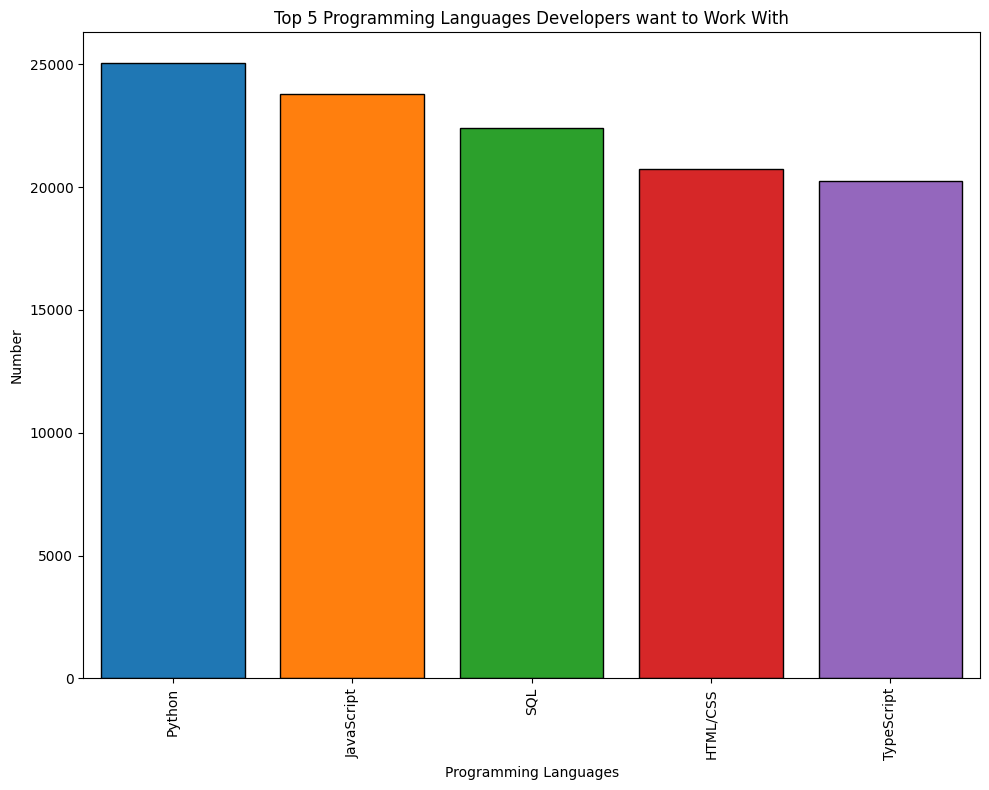

In [63]:
## Write your code here
#columns = LanguageWantToWorkWith
Lang_df = df[['LanguageWantToWorkWith']].copy()

#Standardise
Lang_df['LanguageWantToWorkWith'] = Lang_df['LanguageWantToWorkWith'].astype(str).str.strip()

#splitting into seperate rows
lang_exploded = Lang_df.assign(LanguageWantToWorkWith=Lang_df['LanguageWantToWorkWith'].str.split(';')).explode('LanguageWantToWorkWith')

#clean more after exploding
lang_exploded['LanguageWantToWorkWith'] = lang_exploded['LanguageWantToWorkWith'].str.strip()
lang_exploded = lang_exploded.dropna(subset=['LanguageWantToWorkWith'])

lang_exploded = lang_exploded.dropna()

#Get top5
top_Lang_counts =(lang_exploded['LanguageWantToWorkWith'].value_counts().head(5).sort_values(ascending=False))


#plot stacked bar
top_Lang_counts.plot(kind='bar', figsize=(10,8)) 
bars = plt.bar(top_Lang_counts.index, top_Lang_counts.values, color=colors, edgecolor='black')
plt.title('Top 5 Programming Languages Developers want to Work With')
plt.xlabel('Programming Languages')
plt.ylabel('Number')


plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


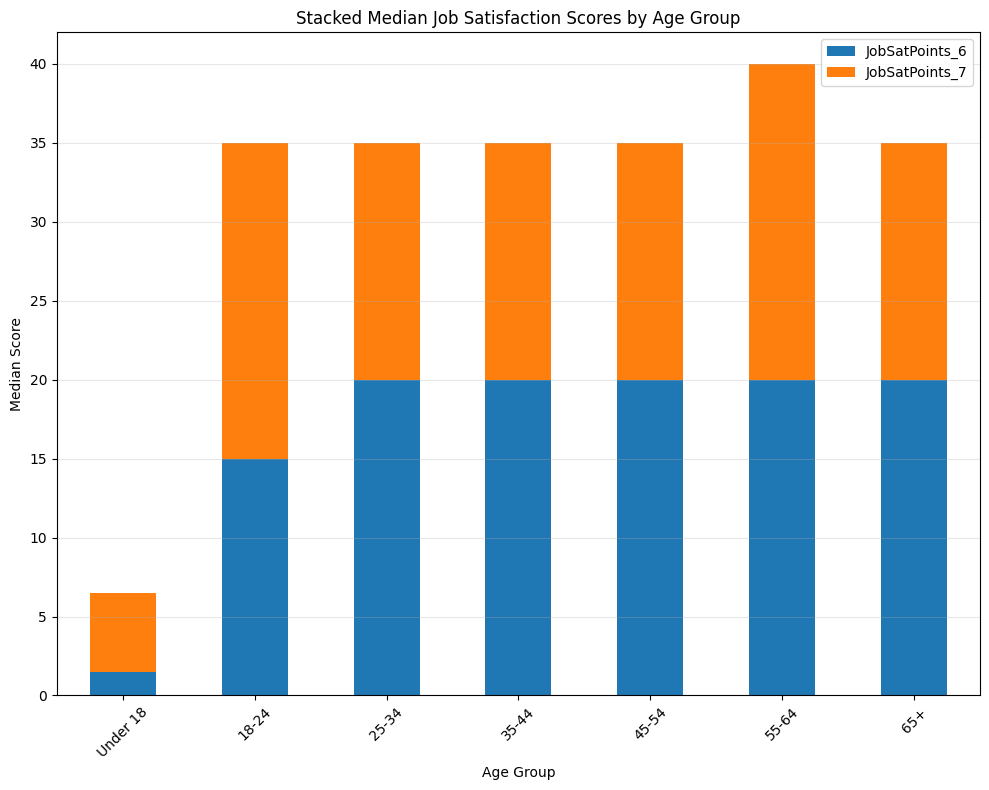

In [64]:
## Write your code here
age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_group'] = df['Age'].map(age_map)

JobSat_df = df[['JobSatPoints_6', 'JobSatPoints_7', 'Age_group']].dropna().copy()

#median values
median_data = JobSat_df.groupby('Age_group')[['JobSatPoints_6', 'JobSatPoints_7']].median()

#ensure proper order of the age groups
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
median_data = median_data.reindex(age_order)

#plot stacked bar
median_data.plot(kind='bar', stacked=True, figsize=(10,8)) 

plt.title('Stacked Median Job Satisfaction Scores by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Score')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



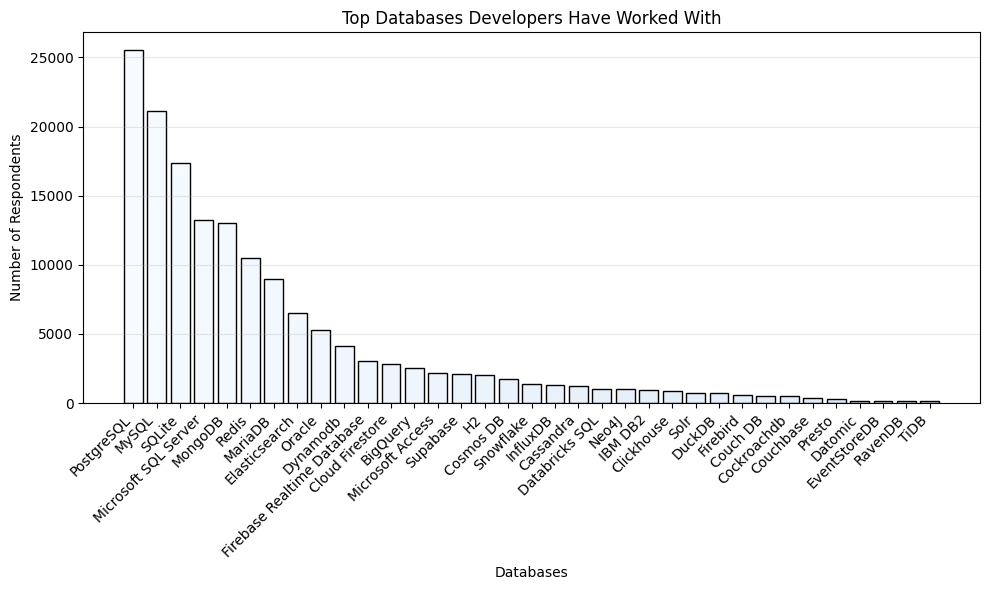

In [67]:
## Write your code here
Data_df = df[['DatabaseHaveWorkedWith']].dropna().copy()

Data_df['DatabaseHaveWorkedWith'] = Data_df['DatabaseHaveWorkedWith'].astype(str).str.strip()

#splitting into seperate rows
Data_exploded = Data_df.assign(DatabaseHaveWorkedWith=Data_df['DatabaseHaveWorkedWith'].str.split(';')).explode('DatabaseHaveWorkedWith')

#clean more after exploding
Data_exploded['DatabaseHaveWorkedWith'] = Data_exploded['DatabaseHaveWorkedWith'].str.strip()

#Remove missing values
Data_exploded = Data_exploded.dropna()
Data_exploded = Data_exploded[Data_exploded['DatabaseHaveWorkedWith'] != '']

top_dbs =(Data_exploded['DatabaseHaveWorkedWith'].value_counts().sort_values(ascending=False))

colors = plt.cm.Blues(range(len(top_dbs)))

plt.figure(figsize=(10, 6))
bars = plt.bar(top_dbs.index, top_dbs.values, color=colors, edgecolor='black')
plt.title('Top Databases Developers Have Worked With')
plt.xlabel('Databases')
plt.ylabel('Number of Respondents')


plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



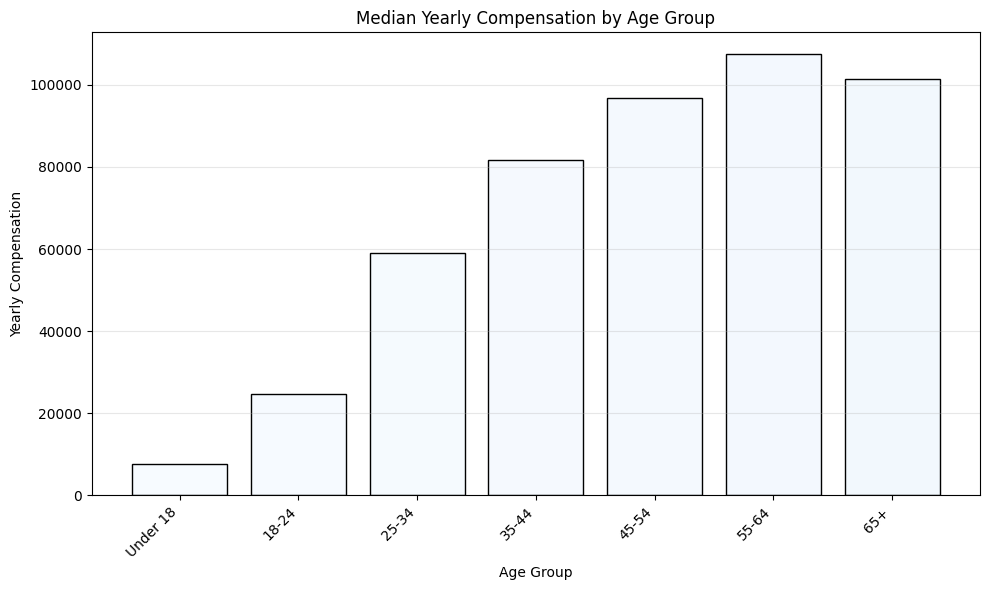

In [72]:
## Write your code here
age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',    
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'}

df['Age_group'] = df['Age'].map(age_map)

Comp_df = df[['ConvertedCompYearly', 'Age_group']].dropna().copy()

#log scale, help with extreme salaries
Comp_df = Comp_df[Comp_df['ConvertedCompYearly'] < 300000]

#calculate the median compensation per age
median_comp = Comp_df.groupby('Age_group')['ConvertedCompYearly'].median()

age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
#sort by the age
median_comp = median_comp.reindex(age_order)

colors = plt.cm.Blues(range(len(median_comp)))

plt.figure(figsize=(10, 6))
bars = plt.bar(median_comp.index, median_comp.values, color=colors, edgecolor='black')
plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Yearly Compensation')


plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



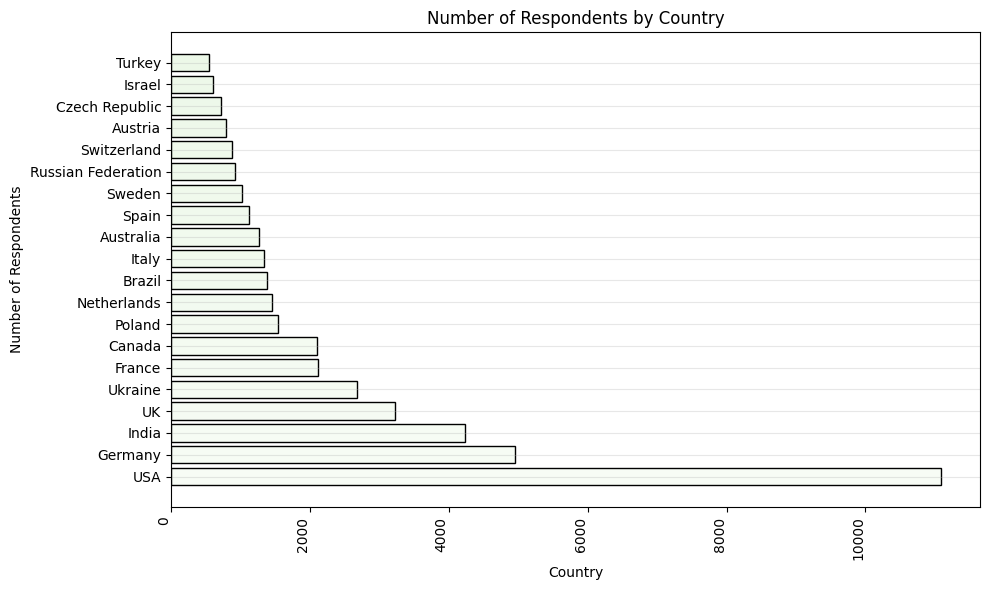

In [84]:
## Write your code here
df['short_country'] = (df['Country'].str.replace('United States of America', 'USA', regex=False).str.replace('United Kingdom of Great Britain and Northern Ireland', 'UK', regex=False)
                       .str.replace(r',.*', '', regex=True).str.strip())

#count the number of responses per country
Country_count = df['short_country'].value_counts()

top_countries = Country_count[Country_count >=20].index #(may need to adjust this, trial and error)(originally started at 20)
df_filtered = df[df['short_country'].isin(top_countries)].copy()

country_counts_filtered = df_filtered['short_country'].value_counts().head(20)

colors = plt.cm.Greens(range(len(country_counts_filtered)))


plt.figure(figsize=(10, 6))

bars = plt.barh(country_counts_filtered.index, country_counts_filtered.values, color=colors, edgecolor='black')
plt.title('Number of Respondents by Country')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')


plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
